# 🛍️ Shopping Mall Customer Segmentation
## Member X — Gaussian Mixture Model (GMM)
**Dataset:** Shopping_Mall_Customer_Segmentation_Data_.csv  
**Algorithm:** Gaussian Mixture Model (GMM)  
**Task:** Unsupervised Learning — Customer Segmentation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Pre-processed Data
> Data was already cleaned and scaled in `step0_eda_preprocessing_no_pca.ipynb`.
> This GMM version uses **scaled features directly** without PCA.


In [2]:
import numpy as np
import pandas as pd

# 加载你 step0 处理好的完整数据
df = pd.read_csv('data/data_preprocessed.csv')
print(f"数据加载成功，当前共有 {df.shape[0]} 条记录")

数据加载成功，当前共有 15079 条记录


In [3]:
# 1. 自动抓取所有分箱列，但排除掉 Age_Group 这个字符串列
# 确保只选取数值型（0/1）的分箱特征
age_bin_cols = [col for col in df.columns if col.startswith('Age_') and col != 'Age_Group']

# 2. 定义最终参与聚类的特征列表
# 这里的 'Gender_Enum' 对应你在 step0 里 map 好的 0/1 数值
##features_to_use = ['Gender_Enum', 'Annual Income', 'Spending Score'] + age_bin_cols
features_to_use = ['Age', 'Annual Income', 'Spending Score']
# 3. 提取矩阵
X = df[features_to_use]

# --- 检查区：如果打印出来有 object 类型，说明还是选错了 ---
print("参与模型的特征列:", X.columns.tolist())
print("数据类型检查:\n", X.dtypes)

# 4. 标准化 (这里就不会再报 String to Float 的错误了)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\n✅ 特征矩阵准备就绪，形状:', X_scaled.shape)

参与模型的特征列: ['Age', 'Annual Income', 'Spending Score']
数据类型检查:
 Age               int64
Annual Income     int64
Spending Score    int64
dtype: object

✅ 特征矩阵准备就绪，形状: (15079, 3)


## 3. Select Optimal Number of Clusters (BIC)
> GMM does not use bandwidth like MeanShift.  
> Instead, we test different values of **K** and choose the best one using **BIC** (lower is better).


In [4]:
bic_scores = []
aic_scores = []
k_range = range(2, 20)

for k in k_range:
    model = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        random_state=42,
        n_init=5
    )
    model.fit(X_scaled)
    bic_scores.append(model.bic(X_scaled))
    aic_scores.append(model.aic(X_scaled))

best_k = list(k_range)[np.argmin(bic_scores)]
print(f'✅ Best K selected by BIC: {best_k}')

✅ Best K selected by BIC: 19


## 4. BIC / AIC Visualization

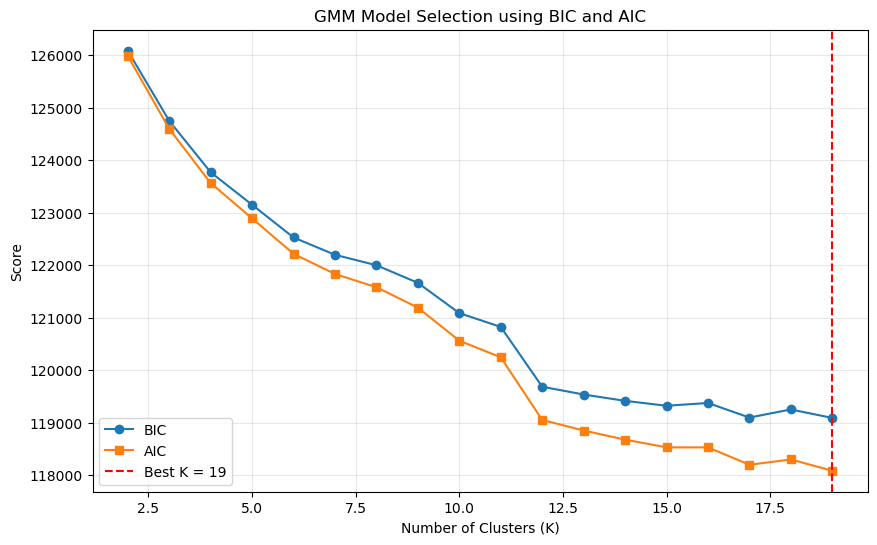

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), bic_scores, marker='o', label='BIC')
plt.plot(list(k_range), aic_scores, marker='s', label='AIC')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title('GMM Model Selection using BIC and AIC')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Train GMM Model
> Train the final Gaussian Mixture Model using the selected number of clusters.


In [6]:
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='diag',
    random_state=42,
    n_init=5
)
gmm.fit(X_scaled)

cluster_labels = gmm.predict(X_scaled)
cluster_probs = gmm.predict_proba(X_scaled)

# 🔥 这里把 df_clean 全部改成了 df
df['Cluster'] = cluster_labels
n_clusters = len(np.unique(cluster_labels))

print(f'Number of clusters found by GMM: {n_clusters}')
print('\nCluster Distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f'  Cluster {c}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

Number of clusters found by GMM: 19

Cluster Distribution:
  Cluster 0: 616 customers (4.1%)
  Cluster 1: 1572 customers (10.4%)
  Cluster 2: 800 customers (5.3%)
  Cluster 3: 694 customers (4.6%)
  Cluster 4: 584 customers (3.9%)
  Cluster 5: 620 customers (4.1%)
  Cluster 6: 1045 customers (6.9%)
  Cluster 7: 439 customers (2.9%)
  Cluster 8: 552 customers (3.7%)
  Cluster 9: 1549 customers (10.3%)
  Cluster 10: 494 customers (3.3%)
  Cluster 11: 556 customers (3.7%)
  Cluster 12: 592 customers (3.9%)
  Cluster 13: 606 customers (4.0%)
  Cluster 14: 558 customers (3.7%)
  Cluster 15: 1268 customers (8.4%)
  Cluster 16: 414 customers (2.7%)
  Cluster 17: 922 customers (6.1%)
  Cluster 18: 1198 customers (7.9%)


## 6. Evaluation Metrics

In [7]:
import pandas as pd
import pickle
# Evaluation metrics
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)

print('=' * 72)
print('                GMM EVALUATION METRICS')
print('=' * 72)
print(f'  Algorithm                 : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected           : {best_k}')
print(f'  Input Feature Space       : X_scaled')
print(f'  Silhouette Score          : {sil:.4f}  (higher = better)')
print(f'  Davies-Bouldin Index      : {dbi:.4f}  (lower = better)')
print(f'  Final BIC Score           : {gmm.bic(X_scaled):.2f}')
print(f'  Final AIC Score           : {gmm.aic(X_scaled):.2f}')
print(f'  Noise Points              : 0')
print('=' * 72)


decision_df = pd.DataFrame([
    {
        'Pipeline': 'Final: GMM on X_scaled',
        'K': best_k,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(dbi, 4),
        'BIC': round(gmm.bic(X_scaled), 2),
        'AIC': round(gmm.aic(X_scaled), 2),
        'Noise': 0
    }
])

print('\n=== Final decision support ===')
print(decision_df.to_string(index=False))

# User explanation（和你其他模型统一）
print('\n📌 User-facing explanation:')
print('   1. GMM models data as a mixture of Gaussian distributions.')
print('   2. Each customer is assigned probabilistically to clusters.')
print('   3. BIC and AIC are used to determine the optimal number of clusters.')
print('   4. Silhouette and Davies-Bouldin evaluate cluster separation and compactness.')
print('   5. GMM does not produce noise points; all data points are assigned to clusters.')

# Save scores（统一格式🔥）
scores = {
    'algorithm': 'GMM',
    'n_clusters': int(best_k),
    'silhouette': round(float(sil), 4),
    'davies_bouldin': round(float(dbi), 4),
    'bic': round(float(gmm.bic(X_scaled)), 2),
    'aic': round(float(gmm.aic(X_scaled)), 2),
    'noise': 0
}

pickle.dump(scores, open('gmm_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('gmm_labels.pkl', 'wb'))

print('\n✅ GMM scores saved.')

                GMM EVALUATION METRICS
  Algorithm                 : Gaussian Mixture Model (GMM)
  Best K Selected           : 19
  Input Feature Space       : X_scaled
  Silhouette Score          : 0.1808  (higher = better)
  Davies-Bouldin Index      : 1.0486  (lower = better)
  Final BIC Score           : 119089.56
  Final AIC Score           : 118083.58
  Noise Points              : 0

=== Final decision support ===
              Pipeline  K  Silhouette  Davies-Bouldin       BIC       AIC  Noise
Final: GMM on X_scaled 19      0.1808          1.0486 119089.56 118083.58      0

📌 User-facing explanation:
   1. GMM models data as a mixture of Gaussian distributions.
   2. Each customer is assigned probabilistically to clusters.
   3. BIC and AIC are used to determine the optimal number of clusters.
   4. Silhouette and Davies-Bouldin evaluate cluster separation and compactness.
   5. GMM does not produce noise points; all data points are assigned to clusters.

✅ GMM scores saved.


## 7. Cluster Visualization (Original Feature Space)
> Since PCA is not used, we visualise the clustering result directly in the original scaled feature space.


In [8]:
feature_cols = ['Annual Income', 'Spending Score', 'Age']
# 🔥 把 df_clean 改成 df
X_vis = df[feature_cols].values

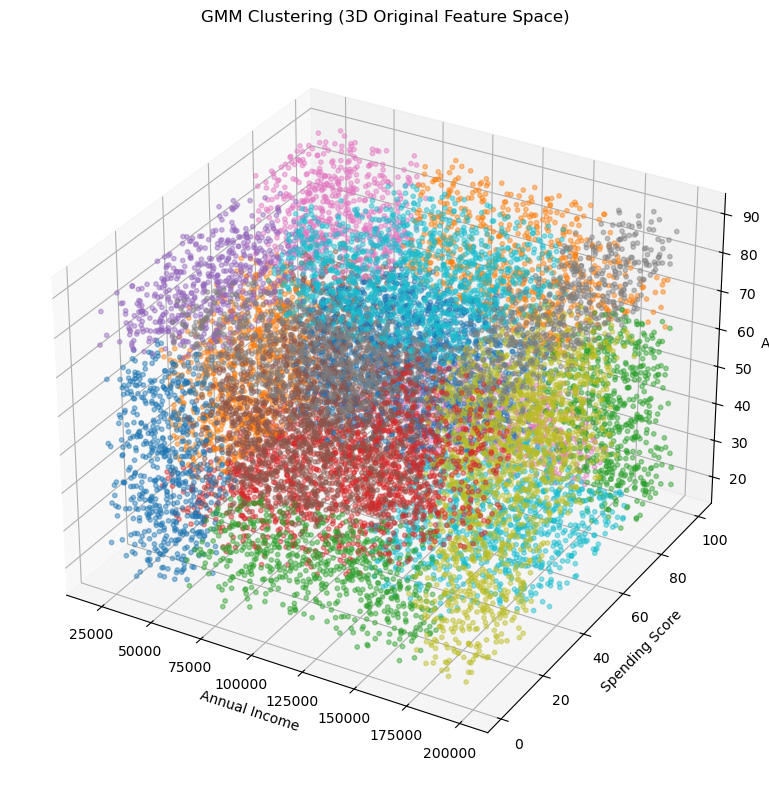

In [9]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Annual Income'],
    df['Spending Score'],
    df['Age'],
    c=cluster_labels,
    cmap='tab10',
    s=10,
    alpha=0.45
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('GMM Clustering (3D Original Feature Space)')
plt.tight_layout()
plt.show()

## 8. Cluster Profile Analysis

In [10]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(2)
profile['Count'] = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(2)
print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual Income,Spending Score,Count,% of Total
Cluster,,,,,
0,44.41,40383.42,11.76,616,4.09
1,51.80,100501.01,69.94,1572,10.43
2,49.97,37335.68,48.89,800,5.31
3,71.32,128332.09,92.27,694,4.60
4,42.29,179871.75,87.12,584,3.87
5,29.81,117251.72,11.30,620,4.11
6,26.24,69964.57,50.04,1045,6.93
7,66.05,167249.59,8.26,439,2.91
8,80.17,39285.36,32.94,552,3.66


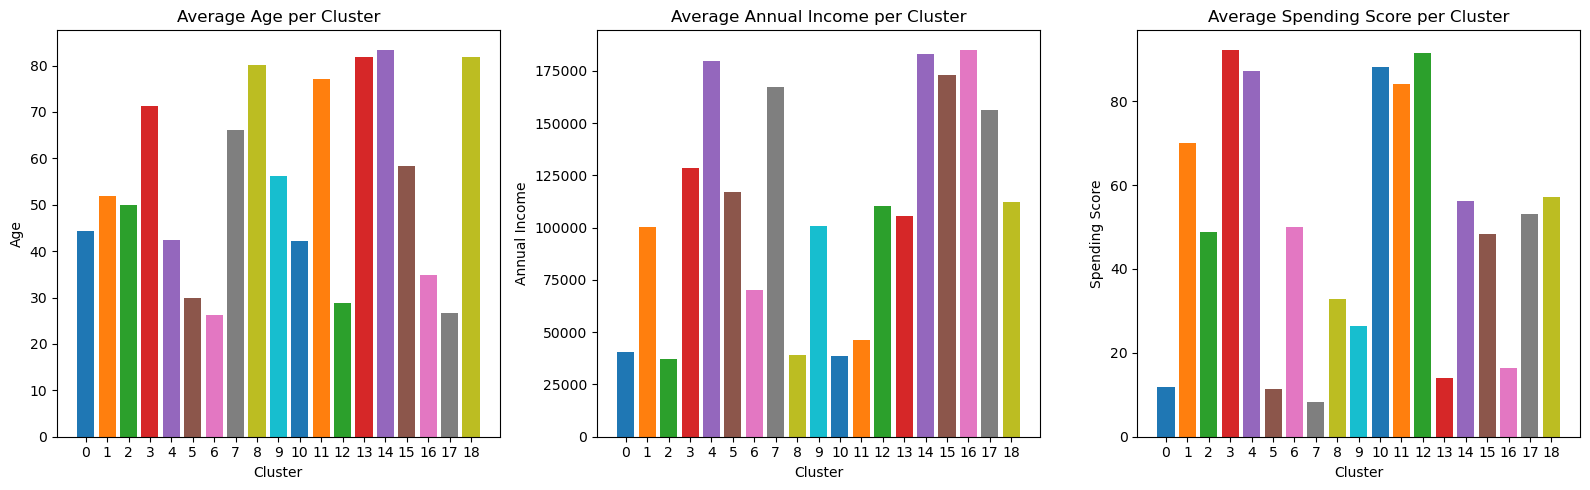

In [11]:
# Bar chart of cluster averages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income', 'Spending Score']
palette_bar = sns.color_palette('tab10', n_clusters)

for i, feat in enumerate(features):
    cluster_means = df.groupby('Cluster')[feat].mean()
    axes[i].bar(cluster_means.index.astype(str), cluster_means.values, color=palette_bar)
    axes[i].set_title(f'Average {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('gmm_cluster_profiles.png', dpi=150)
plt.show()

## 9. Membership Probability Analysis

In [12]:
prob_df = pd.DataFrame(cluster_probs, columns=[f'Prob_Cluster_{i}' for i in range(n_clusters)])
prob_df['Predicted_Cluster'] = cluster_labels

print('First 10 customers with cluster membership probabilities:')
prob_df.head(10)

First 10 customers with cluster membership probabilities:


,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2,Prob_Cluster_3,Prob_Cluster_4,Prob_Cluster_5,Prob_Cluster_6,Prob_Cluster_7,Prob_Cluster_8,Prob_Cluster_9,Prob_Cluster_10,Prob_Cluster_11,Prob_Cluster_12,Prob_Cluster_13,Prob_Cluster_14,Prob_Cluster_15,Prob_Cluster_16,Prob_Cluster_17,Prob_Cluster_18,Predicted_Cluster
0,1.718325e-34,0.024018,3.215021e-22,1.970879e-03,1.265978e-01,3.332788e-23,2.412072e-03,6.395259e-45,7.912891e-28,0.000006,1.019692e-18,1.176189e-12,6.563395e-01,3.426698e-32,1.019367e-24,4.651571e-03,3.317797e-12,1.840044e-01,1.390900e-18,12
1,5.983319e-47,0.014762,1.165082e-35,2.470723e-01,6.691227e-01,9.060126e-30,8.773110e-11,5.690555e-50,1.577261e-28,0.000002,6.094599e-31,6.532082e-13,2.859372e-04,1.692112e-22,8.652873e-06,6.873417e-02,2.807864e-12,7.539014e-07,1.197583e-05,4
2,2.451990e-15,0.745443,7.344569e-03,1.970660e-02,1.368788e-12,9.921449e-20,4.356111e-08,1.393062e-34,4.868896e-04,0.004822,1.421183e-02,2.054482e-01,8.567803e-06,2.565065e-13,3.415506e-24,1.544812e-08,4.035489e-32,1.347842e-09,2.528556e-03,1
3,5.916414e-08,0.017510,9.673297e-02,1.200938e-11,3.787429e-18,5.977773e-09,8.824929e-01,7.987898e-24,6.333587e-16,0.002022,4.422003e-04,3.552929e-09,1.600596e-07,2.218631e-26,3.561852e-55,2.676750e-12,3.154886e-35,7.995002e-04,3.878474e-23,6
4,8.780322e-29,0.024743,2.507460e-22,2.533912e-05,1.101895e-01,2.974552e-16,9.252536e-03,1.682358e-32,3.099709e-30,0.000076,8.172111e-20,2.809325e-14,4.902619e-02,4.917303e-31,2.305215e-29,1.110335e-02,9.659680e-09,7.955835e-01,3.102487e-22,17
5,2.937399e-18,0.047815,8.320703e-23,1.383856e-16,1.121091e-05,4.433388e-04,7.832456e-04,1.742843e-07,2.068198e-22,0.143004,5.032196e-27,1.804891e-14,1.081201e-15,7.135359e-12,1.481563e-14,6.829540e-01,1.519510e-02,1.097937e-01,5.933810e-11,15
6,1.257733e-19,0.002196,1.782804e-25,2.308223e-20,1.144706e-06,2.442499e-03,5.146403e-03,1.261974e-07,2.872373e-30,0.009843,3.606283e-30,4.345390e-19,3.576673e-17,3.134649e-20,5.673381e-26,5.668075e-02,3.464151e-02,8.890487e-01,1.977604e-20,17
7,7.673758e-02,0.000191,1.450429e-03,1.718808e-35,1.280110e-23,4.784372e-01,4.088116e-01,3.055622e-07,7.077187e-16,0.032804,1.120074e-16,2.262932e-16,3.190863e-31,2.001322e-20,9.186981e-49,2.755431e-10,2.962685e-25,1.568464e-03,4.641247e-23,5
8,2.729948e-03,0.000557,3.408849e-02,1.641021e-20,1.187983e-25,4.257116e-13,1.334470e-19,8.211635e-12,8.080039e-01,0.027000,1.022840e-10,1.156674e-05,6.991584e-30,3.072277e-02,2.562037e-30,4.413986e-13,6.421240e-40,1.495721e-21,9.688680e-02,8
9,4.597290e-01,0.000130,4.889011e-03,9.571897e-45,1.083588e-29,2.250781e-04,1.513677e-08,2.848687e-05,1.059765e-02,0.517880,5.531162e-22,1.860621e-13,2.319714e-47,6.415336e-03,2.218403e-27,3.351375e-10,3.659013e-29,9.515918e-11,1.048323e-04,9


## 10. Summary

In [13]:
print('=' * 55)
print('         GMM CLUSTERING — FINAL SUMMARY')
print('=' * 55)
print(f'  Algorithm             : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected       : {best_k}')
print(f'  Covariance Type       : diag')
print(f'  Total Customers       : {len(df)}')
print(f'  Silhouette Score      : {sil:.4f}')
print(f'  Davies-Bouldin Index  : {dbi:.4f}')
print(f'  Final BIC Score       : {gmm.bic(X_scaled):.2f}')
print('=' * 55)
print('\nKey advantage of GMM:')
print('  - Provides soft clustering using membership probabilities')
print('  - Can model overlapping clusters better than K-Means')


         GMM CLUSTERING — FINAL SUMMARY
  Algorithm             : Gaussian Mixture Model (GMM)
  Best K Selected       : 19
  Covariance Type       : diag
  Total Customers       : 15079
  Silhouette Score      : 0.1808
  Davies-Bouldin Index  : 1.0486
  Final BIC Score       : 119089.56

Key advantage of GMM:
  - Provides soft clustering using membership probabilities
  - Can model overlapping clusters better than K-Means


          CUSTOMER CLUSTER PROFILES
               Age  Annual Income  Spending Score
Cluster                                          
0        44.412338   40383.417208       11.759740
1        51.796438  100501.007634       69.938931
2        49.973750   37335.685000       48.891250
3        71.317003  128332.089337       92.268012
4        42.291096  179871.753425       87.118151
5        29.811290  117251.719355       11.304839
6        26.244019   69964.565550       50.041148
7        66.045558  167249.594533        8.259681
8        80.170290   39285.364130       32.938406
9        56.220788  100796.267269       26.371207
10       42.080972   38396.732794       88.046559
11       77.129496   46068.899281       84.201439
12       28.804054  110437.209459       91.393581
13       81.795380  105786.127063       13.980198
14       83.412186  183214.286738       56.096774
15       58.345426  173061.439274       48.342271
16       34.942029  185078.198068       16.449275
17       26.74

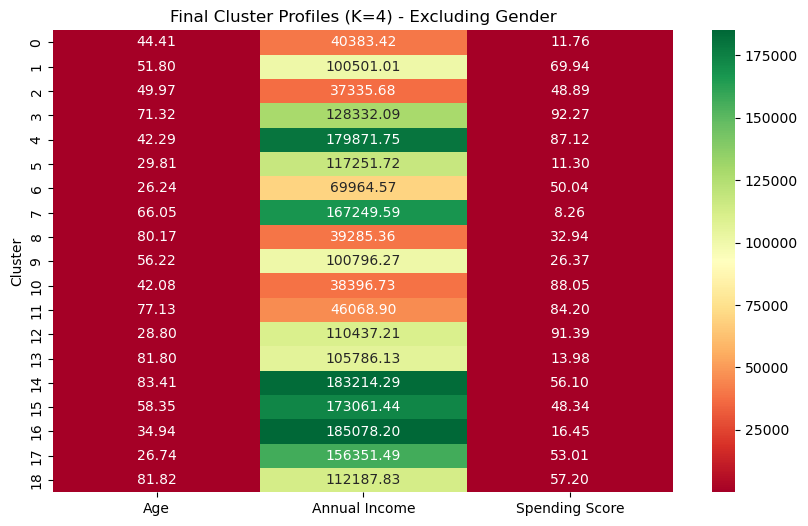

In [14]:
# 🔥 全部统一使用 df
cluster_profiles = df.groupby('Cluster').mean(numeric_only=True)

print("=============================================")
print("          CUSTOMER CLUSTER PROFILES")
print("=============================================")
print(cluster_profiles)
print("=============================================")

print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plot_features = ['Age', 'Annual Income', 'Spending Score']
display_profiles = df.groupby('Cluster')[plot_features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(display_profiles, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Final Cluster Profiles (K=4) - Excluding Gender')
plt.show()

---
# 🔮 Predict Customer Segment
> Enter a new customer's details below and the trained model will predict which segment they belong to.


In [ ]:
# ============================================================
#  ✏️  ENTER CUSTOMER DETAILS HERE
# ============================================================
input_age            = int(input('Enter Age           : '))
input_gender         = input('Enter Gender        (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

# 1. 转换性别 (Male=1, Female=0)
gender_encoded = 1 if input_gender == 'Male' else 0

# 2. 转换 10 段年龄分箱 (解决特征维度不匹配问题)
age_bin_cols = [col for col in df.columns if col.startswith('Age_Bin_')]
age_bins_values = [0] * len(age_bin_cols)
bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ['<20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '>60']

import bisect
idx = bisect.bisect_left(bins, input_age) - 1
if 0 <= idx < len(labels):
    target_label = 'Age_Bin_' + labels[idx]
    if target_label in age_bin_cols:
        age_bins_values[age_bin_cols.index(target_label)] = 1

# 3. 拼接成 13 维特征: [Gender, Income, Score, Age_bin1... Age_bin10]
new_customer_features = [gender_encoded, input_annual_income, input_spending_score] + age_bins_values

# predict in scaled feature space
new_customer_scaled = scaler.transform([new_customer_features])
predicted_cluster = gmm.predict(new_customer_scaled)[0]
membership_probs  = gmm.predict_proba(new_customer_scaled)[0]

# profile from original feature space
cluster_profile = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']].mean()
cluster_size = (df['Cluster'] == predicted_cluster).sum()

print()
print('=' * 55)
print('             GMM — PREDICTION RESULT')
print('=' * 55)
print(f'  Input  → Age: {input_age}, Gender: {input_gender}')
print(f'           Annual Income: {input_annual_income:,.0f}')
print(f'           Spending Score: {input_spending_score:.1f}')
print()
print(f'   Predicted Cluster : {predicted_cluster}')
print(f'   Cluster Size      : {cluster_size} customers')
print()
print('  Cluster Membership Probabilities:')
for i, prob in enumerate(membership_probs):
    print(f'    Cluster {i}: {prob:.4f}')
print()
print('  Cluster Average Profile:')
print(f'    Average Age           : {cluster_profile["Age"]:.1f}')
print(f'    Average Annual Income : {cluster_profile["Annual Income"]:,.0f}')
print(f'    Average Spending Score: {cluster_profile["Spending Score"]:.1f}')
print('=' * 55)

In [ ]:
cluster_data = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']]

print("\n  Cluster Range:")
print(f"    Age Range           : {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
print(f"    Annual Income Range : {cluster_data['Annual Income'].min():,.0f} - {cluster_data['Annual Income'].max():,.0f}")
print(f"    Spending Score Range: {cluster_data['Spending Score'].min():.0f} - {cluster_data['Spending Score'].max():.0f}")

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# ============================================================
#  3D INTERACTIVE PLOT (No PCA needed since we have exactly 3 features!)
# ============================================================

# 1. 准备绘图数据 (直接使用真实的业务特征)
df_plot = df[['Age', 'Annual Income', 'Spending Score']].copy()
df_plot['Cluster'] = cluster_labels.astype(str)

# 2. 画出可以互动的 3D 散点图
fig = px.scatter_3d(
    df_plot,
    x='Annual Income',       # X轴：收入
    y='Spending Score',      # Y轴：消费得分
    z='Age',                 # Z轴(深度)：年龄
    color='Cluster',
    opacity=0.35,            # 透明度调低，显得像 2D Seaborn 图一样清爽
    title='GMM Clustering — New Customer Prediction',
    color_discrete_sequence=px.colors.qualitative.Pastel # 柔和的颜色
)

# 3. 把“新客户(YOU)”高亮放进去，并明确标出他被分到了哪个 Cluster
fig.add_trace(go.Scatter3d(
    x=[input_annual_income],
    y=[input_spending_score],
    z=[input_age],
    mode='markers+text',
    text=[f'⭐ YOU (Cluster {predicted_cluster})'],  # 👈 这里把 Cluster 补上了！
    textposition='top center',
    textfont=dict(size=12, color='black', weight='bold'),
    marker=dict(size=12, color='red', symbol='diamond', line=dict(color='black', width=2)),
    name=f'New Customer -> Cluster {predicted_cluster}' # 👈 图例里也写清楚了
))

# 4. 关键魔法：调整初始视角 (Camera Angle)
fig.update_layout(
    scene=dict(
        xaxis_title='Annual Income ($)',
        yaxis_title='Spending Score (1-100)',
        zaxis_title='Age',
        camera=dict(
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=0, y=-2.0, z=0.1)  # 正视XY面，略微带一点俯视
        )
    ),
    legend_title_text='Cluster',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()